# Model Building

## Import Libraries

In [1]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached grpcio-1.80.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dty


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 3.4 MB/s eta 0:00:03
   ----------------- ---------------------- 3.9/8.9 MB 12.4 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 19.7 MB/s  0:00:00
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   ----- ---------------------------------- 5.2/41.3 MB 24.5 MB/s eta 0:00:02
   -------- ------------------------------- 9.2/41.3 MB 23.8 MB/s eta 0:00:02
   --------------- ------------------------ 16.0/41.3 MB 25.8 MB/s eta 0:00:01
   -------------------- ------------------- 21.2/41.3 MB 25.8 MB/s eta 0:00:01
   ----------------------- ---------------- 24.1/41.3 MB 24.2 MB/s eta 0:00:01
   -------------------------- ------------- 27.3/41.3 MB 22.2 MB/s eta 0:00:01
   ----------------------------- ---------- 30.7/41.3 MB 21.4 MB/s eta 0:00:01
   --------------------------------- ------ 34.3/41.3 MB 20.8 MB/s eta 0:00:01
   -


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 6.5 MB/s eta 0:00:16
   --- ------------------------------------ 9.4/101.7 MB 21.7 MB/s eta 0:00:05
   ----- ---------------------------------- 13.4/101.7 MB 27.9 MB/s eta 0:00:04
   ------ --------------------------------- 16.5/101.7 MB 19.6 MB/s eta 0:00:05
   -------- ------------------------------- 20.4/101.7 MB 20.5 MB/s eta 0:00:04
   --------- ------------------------------ 25.2/101.7 MB 19.9 MB/s eta 0:00:04
   --------------- ------------------------ 40.1/101.7 MB 27.7 MB/s eta 0:00:03
   -------------------- ------------------- 52.7/101.7 MB 31.7 MB/s eta 0:00:02
   -------------------------- ------------- 66.3/101.7 MB 35.5 MB/s eta 0:00:01
   ------------------------------- -------- 80.0/101.7 MB 38.6 MB/s eta 0:00:01
   ------------------------------------- -- 94.1/101.7 MB 41.


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

## Load Cleaned Dataset

In [8]:
# Load cleaned dataset

df = pd.read_csv('clean_energy_consumption_dataset.csv')

# Display first rows
df.head()

,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,7,3,6,0,29.733927,71.833625,4682.0,4,5.085954,2.083080,0.093722,1488.317801
1,4,17,0,0,17.011337,52.286668,4025.0,96,0.000000,7.729044,1.251077,1524.238785
2,11,21,0,0,19.408582,57.636140,573.0,37,0.084488,5.738170,3.567341,348.036367
3,8,15,5,0,19.991989,48.958263,3726.0,64,1.103109,6.101714,0.009646,1253.470309
4,5,23,6,0,23.402021,64.717666,636.0,47,2.076862,7.213404,1.160987,371.272816


## Define Features and Target

In [9]:
X = df.drop('EnergyConsumption', axis=1)
y = df['EnergyConsumption']

## Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Create Models

In [12]:
# Linear Regression
lr = LinearRegression()

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# XGBoost
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

## Build Deep Learning Model (Neural Network)

In [13]:
# Build Neural Network
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

# Compile model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

C:\Users\Sheru\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train Models

In [14]:
# Linear Regression
lr.fit(X_train_scaled, y_train)

# Random Forest
rf.fit(X_train, y_train)

# XGBoost
xgb.fit(X_train, y_train)

# Neural Network
history = model.fit( X_train_scaled, y_train, validation_split=0.2, epochs=30, batch_size=32, verbose=1 )

Epoch 1/30
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 92956.9766 - mae: 160.5555 - val_loss: 11657.2764 - val_mae: 71.5761
Epoch 2/30
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 9856.2314 - mae: 61.6447 - val_loss: 8918.7090 - val_mae: 55.5031
Epoch 3/30
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 8714.6250 - mae: 54.5732 - val_loss: 8695.9443 - val_mae: 53.5547
Epoch 4/30
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 8614.2393 - mae: 53.7920 - val_loss: 8785.2305 - val_mae: 53.4321
Epoch 5/30
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 8605.0059 - mae: 53.8466 - val_loss: 8606.7363 - val_mae: 52.8952
Epoch 6/30
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 8588.1738 - mae: 53.6544 - val_loss: 8748.4746 - val_mae: 54.2947
Epoch 7/30
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 8580.1592 - mae: 53.6673 - val_loss: 8700.1240 - val_mae: 53.9314
Epoch 8/30
2337/2337 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 8566.0693 - mae: 53.5551 - val_loss: 86

## Stacking Ensemble Model

In [15]:
estimators = [
    ('rf', rf),
    ('xgb', xgb)
]

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

stack_model.fit(X_train, y_train)

,estimators,"[('rf', ...), ('xgb', ...)]"
,final_estimator,LinearRegression()
,cv,None
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1


## Predictions

In [16]:
pred_lr = lr.predict(X_test_scaled)
pred_dl = model.predict(X_test_scaled).flatten()
pred_rf = rf.predict(X_test)
pred_xgb = xgb.predict(X_test)
pred_stack = stack_model.predict(X_test)

731/731 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step


## Evaluation Function

In [18]:
def evaluate_model(name, y_test, predictions):

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"\n{name}")
    print('-' * 30)
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE : {mae:.3f}")
    print(f"R²  : {r2:.3f}")

## Evaluate All Models

In [23]:
evaluate_model('Linear Regression', y_test, pred_lr)
evaluate_model('Deep Learning Model', y_test, pred_dl)
evaluate_model('Random Forest', y_test, pred_rf)
evaluate_model('XGBoost', y_test, pred_xgb)
evaluate_model('Stacking Ensemble', y_test, pred_stack)


Linear Regression
------------------------------
RMSE: 94.687
MAE : 53.118
R²  : 0.943

Deep Learning Model
------------------------------
RMSE: 95.168
MAE : 53.681
R²  : 0.942

Random Forest
------------------------------
RMSE: 96.357
MAE : 55.315
R²  : 0.941

XGBoost
------------------------------
RMSE: 94.986
MAE : 53.618
R²  : 0.942

Stacking Ensemble
------------------------------
RMSE: 94.950
MAE : 53.542
R²  : 0.942


## Compare Models

In [24]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Deep Learning Model',
        'Random Forest',
        'XGBoost',
        'Stacking Ensemble'
    ],
    'R2 Score': [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_dl),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_xgb),
        r2_score(y_test, pred_stack)
    ]
})

print(results.sort_values(by='R2 Score', ascending=False))

                 Model  R2 Score
0    Linear Regression  0.942775
4    Stacking Ensemble  0.942457
3              XGBoost  0.942413
1  Deep Learning Model  0.942192
2        Random Forest  0.940738


## Best Model Selection

In [21]:
best_model = results.sort_values(by='R2 Score', ascending=False)

print('\nBest Performing Model:')
print(best_model.iloc[0])


Best Performing Model:
Model       Linear Regression
R2 Score             0.942775
Name: 0, dtype: object


## Visualization of Model Performance

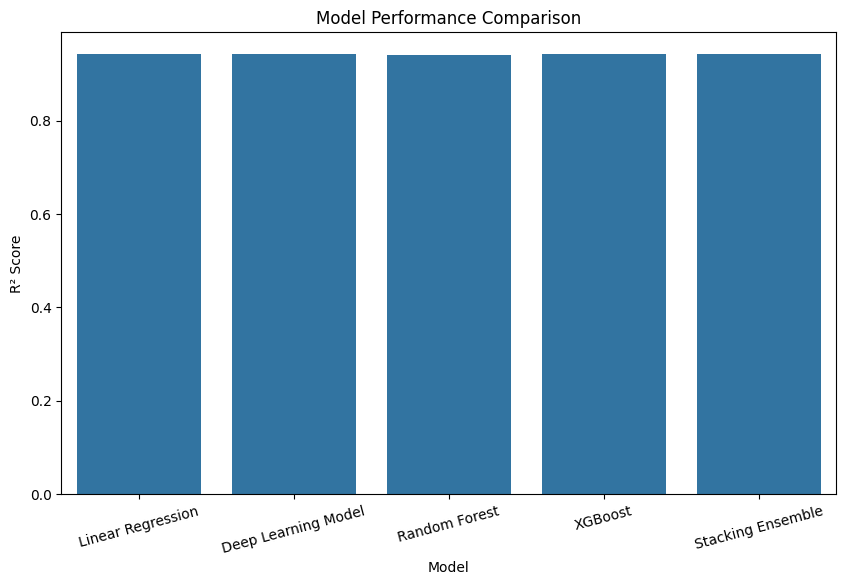

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title('Model Performance Comparison')
plt.xticks(rotation=15)
plt.ylabel('R² Score')
plt.show()

# Plot Actual and Predictive of best model

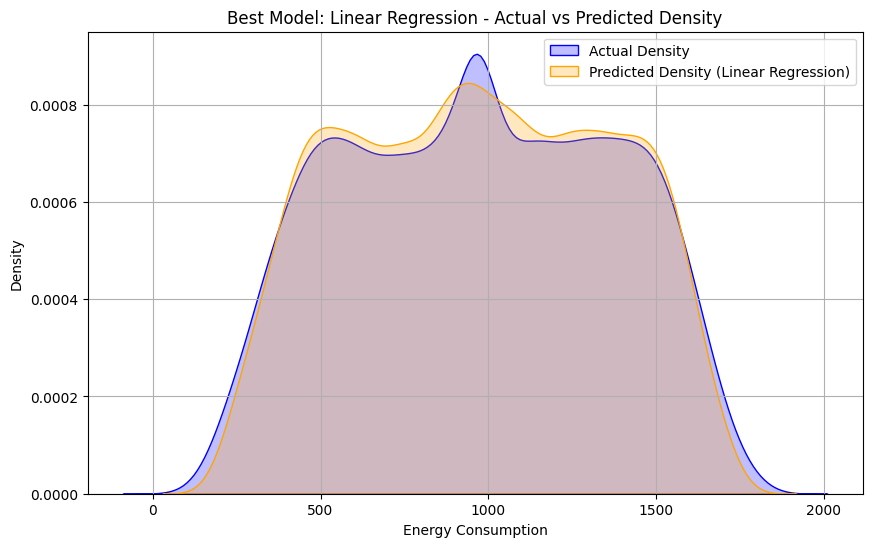

In [47]:
plt.figure(figsize=(10,6))

sns.kdeplot(y_test, label='Actual Density', fill=True, color='blue')
sns.kdeplot(pred_lr, label='Predicted Density (Linear Regression)', fill=True, color='orange')

plt.title("Best Model: Linear Regression - Actual vs Predicted Density")
plt.xlabel("Energy Consumption")
plt.ylabel("Density")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import joblib

# Save trained model
joblib.dump(lr, 'energy_model.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully!")